# ERA5 - Extracción unificada (Todo Chile - 2000-2025)

Extracción de **precipitación total** y **temperatura a 2 m** desde el **ARCO ERA5** de Google Cloud
con `xarray` + `Dask`. El notebook descarga ambas variables en paralelo, cachea por año en disco,
y produce acumulados/promedios diario y mensual, climatología mensual y anomalías, guardando
todo en NetCDF separado por variable.

## 1. Configuración inicial

In [1]:
import os
import time
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from dask.distributed import Client, progress

### Cluster de Dask

El trabajo es E/S de red, así que conviene un solo worker en proceso con muchos hilos
en vez de varios procesos.

In [2]:
client = Client(processes=False, n_workers=1, threads_per_worker=32)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://192.168.1.7:8787/status,
Dashboard: http://192.168.1.7:8787/status,Workers: 1
Total threads: 32,Total memory: 15.30 GiB
Status: running,Using processes: False
Comm: inproc://192.168.1.7/10212/1,Workers: 0
Dashboard: http://192.168.1.7:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: inproc://192.168.1.7/10212/4,Total threads: 32
Dashboard: http://192.168.1.7:61486/status,Memory: 15.30 GiB
Nanny: None,


## 2. Parámetros

In [3]:
# Variables a extraer: 'tp' (precipitación), 't2m' (temperatura), o ambas
VARIABLES = ['tp', 't2m']  # cambiar a ['tp'] o ['t2m'] si solo quieres una

# Configuración del store
URL_ARCO = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'

# Región (Todo Chile)
LAT_NORTE, LAT_SUR = -17.0, -56.0
LON_OESTE, LON_ESTE = -77.0, -66.0

# Período temporal
ANIO_INI, ANIO_FIN = 2000, 2025

# Submuestreo (1 = serie horaria completa; 3 o 6 reduce descarga)
PASO_HORAS = 1
HORAS_POR_TAREA = 24
PASOS_POR_TAREA = max(1, HORAS_POR_TAREA // PASO_HORAS)

# Directorios y salida
DIR_CACHE = Path('cache_era5_chile')
DIR_CACHE.mkdir(exist_ok=True)

SALIDA_NC = {
    'tp': 'era5_tp_chile_2000_2025.nc',
    't2m': 'era5_t2m_chile_2000_2025.nc',
}

## 3. Apertura del store

In [4]:
ds = xr.open_zarr(
    URL_ARCO,
    chunks=None,
    storage_options={'token': 'anon'},
)

print(f'Store abierto: {URL_ARCO}')
print(f'Variables disponibles: {list(ds.data_vars)}')
print(f'Dimensiones: {dict(zip(ds.dims, [ds.dims[d] for d in ds.dims]))}')

Store abierto: gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3
Variables disponibles: ['100m_u_component_of_wind', '100m_v_component_of_wind', '10m_u_component_of_neutral_wind', '10m_u_component_of_wind', '10m_v_component_of_neutral_wind', '10m_v_component_of_wind', '10m_wind_gust_since_previous_post_processing', '2m_dewpoint_temperature', '2m_temperature', 'air_density_over_the_oceans', 'angle_of_sub_gridscale_orography', 'anisotropy_of_sub_gridscale_orography', 'benjamin_feir_index', 'boundary_layer_dissipation', 'boundary_layer_height', 'charnock', 'clear_sky_direct_solar_radiation_at_surface', 'cloud_base_height', 'coefficient_of_drag_with_waves', 'convective_available_potential_energy', 'convective_inhibition', 'convective_precipitation', 'convective_rain_rate', 'convective_snowfall', 'convective_snowfall_rate_water_equivalent', 'downward_uv_radiation_at_the_surface', 'duct_base_height', 'eastward_gravity_wave_surface_stress', 'eastward_turbulent_surface_stres

C:\Users\Javiera\AppData\Local\Temp\ipykernel_10212\4141056883.py:9: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'Dimensiones: {dict(zip(ds.dims, [ds.dims[d] for d in ds.dims]))}')


## 4. Definiciones de variables

Cada variable tiene metadata específica: nombre en el store, conversión de unidades,
operación de agregación temporal (sum o mean).

In [5]:
VAR_CONFIG = {
    'tp': {
        'store_name': 'total_precipitation',
        'short_name': 'tp',
        'long_name': 'Total precipitation',
        'units': 'mm',
        'convert': lambda x: (x.clip(min=0) * 1000),  # m -> mm, recorta ruido negativo
        'agg_func': 'sum',  # acumulado diario/mensual
        'cache_prefix': 'tp_',
        'daily_var': 'daily_total',
        'monthly_var': 'monthly_total',
        'spatial_daily': 'daily_total_spatial',
        'spatial_monthly': 'monthly_total_spatial',
        'clim_desc': 'acumulado diario/mensual por celda',
        'anom_color': lambda y: np.where(y > 0, 'tab:blue', 'tab:orange'),
    },
    't2m': {
        'store_name': '2m_temperature',
        'short_name': 't2m',
        'long_name': '2 metre temperature',
        'units': '°C',
        'convert': lambda x: (x - 273.15),  # K -> °C
        'agg_func': 'mean',  # media diaria/mensual
        'cache_prefix': 't2m_',
        'daily_var': 'daily_mean',
        'monthly_var': 'monthly_mean',
        'spatial_daily': 'daily_mean_spatial',
        'spatial_monthly': 'monthly_mean_spatial',
        'clim_desc': 'media diaria/mensual por celda',
        'anom_color': lambda y: np.where(y > 0, 'tab:red', 'tab:blue'),
    },
}

print(f'Variables a extraer: {VARIABLES}')
print(f'Período: {ANIO_INI}-{ANIO_FIN}')
print(f'Región: lat {LAT_NORTE}..{LAT_SUR}, lon {LON_OESTE}..{LON_ESTE}')

Variables a extraer: ['tp', 't2m']
Período: 2000-2025
Región: lat -17.0..-56.0, lon -77.0..-66.0


## 5. Funciones de recorte y procesamiento

In [6]:
def recorte_horario(anio: int, variable: str):
    '''Recorte lazy de un año, con unidades convertidas. No descarga nada.'''
    cfg = VAR_CONFIG[variable]
    da = ds[cfg['store_name']].sel(
        latitude=slice(LAT_NORTE, LAT_SUR),
        longitude=slice(LON_OESTE % 360, LON_ESTE % 360),
        time=slice(f'{anio}-01-01 00:00', f'{anio}-12-31 23:00'),
    )
    if PASO_HORAS > 1:
        da = da.isel(time=slice(None, None, PASO_HORAS))

    da = da.chunk({'time': PASOS_POR_TAREA, 'latitude': -1, 'longitude': -1})
    da = cfg['convert'](da).rename(cfg['short_name'])
    da.attrs = {
        'long_name': cfg['long_name'],
        'short_name': cfg['short_name'],
        'units': cfg['units'],
    }
    return da


def computar_con_reintentos(obj, intentos=4, espera=60):
    '''Computa un objeto perezoso reintentando ante cortes de red.'''
    for intento in range(1, intentos + 1):
        try:
            fut = obj.persist(retries=3)
            progress(fut)
            return fut.compute(retries=3)
        except Exception as exc:
            print(f'  intento {intento}/{intentos} falló: {exc!r}')
            if intento == intentos:
                raise
            print(f'  reintentando en {espera * intento} s...')
            time.sleep(espera * intento)


print('Funciones definidas.')

Funciones definidas.


## 6. Descarga con caché incremental por año

In [7]:
for variable in VARIABLES:
    cfg = VAR_CONFIG[variable]
    print(f'\n=== Extrayendo {cfg["long_name"]} ===')

    # el encoding depende solo de la variable, no del año: se calcula una vez
    enc = {cfg['short_name']: {'zlib': True, 'complevel': 4, 'dtype': 'float32'}}

    for anio in range(ANIO_INI, ANIO_FIN + 1):
        destino = DIR_CACHE / f'{cfg["cache_prefix"]}{anio}.nc'
        if destino.exists():
            print(f'{anio}: ya en caché ({destino.stat().st_size / 1e6:.1f} MB)')
            continue

        print(f'{anio}: descargando...')
        t0 = time.time()
        datos = computar_con_reintentos(recorte_horario(anio, variable))

        tmp = destino.with_suffix('.tmp.nc')
        datos.to_netcdf(tmp, engine='netcdf4', encoding=enc)
        tmp.replace(destino)
        print(f'{anio}: listo en {time.time() - t0:.0f} s ({datos.sizes["time"]} pasos)')


=== Extrayendo Total precipitation ===
2000: ya en caché (98.7 MB)
2001: ya en caché (96.3 MB)
2002: ya en caché (97.5 MB)
2003: ya en caché (92.8 MB)
2004: ya en caché (95.0 MB)
2005: ya en caché (95.0 MB)
2006: ya en caché (94.8 MB)
2007: ya en caché (94.1 MB)
2008: ya en caché (93.2 MB)
2009: ya en caché (92.9 MB)
2010: ya en caché (92.9 MB)
2011: ya en caché (93.1 MB)
2012: ya en caché (93.9 MB)
2013: ya en caché (91.1 MB)
2014: ya en caché (95.0 MB)
2015: ya en caché (93.6 MB)
2016: ya en caché (88.5 MB)
2017: ya en caché (96.3 MB)
2018: ya en caché (93.5 MB)
2019: descargando...
2019: listo en 226 s (8760 pasos)
2020: descargando...
2020: listo en 224 s (8784 pasos)
2021: descargando...
2021: listo en 222 s (8760 pasos)
2022: descargando...
2022: listo en 223 s (8760 pasos)
2023: descargando...
2023: listo en 221 s (8760 pasos)
2024: descargando...
2024: listo en 219 s (8784 pasos)
2025: descargando...
2025: listo en 218 s (8760 pasos)

=== Extrayendo 2 metre temperature ===
200

## 7. Consolidación y agregación temporal

In [8]:
# Diccionario para los datasets finales
resultados = {}

for variable in VARIABLES:
    cfg = VAR_CONFIG[variable]
    print(f'\n=== Procesando {cfg["long_name"]} ===')

    # Cargar series cacheadas
    archivos = sorted(DIR_CACHE.glob(f'{cfg["cache_prefix"]}*.nc'))
    data = xr.open_mfdataset(archivos, combine='by_coords', engine='netcdf4')[cfg['short_name']].load()

    print(f'{data.sizes["time"]} pasos · {data.nbytes / 1e6:.0f} MB en memoria')

    # Recortar al último paso con datos válidos
    validos = data.notnull().any(('latitude', 'longitude')).values
    if not validos.all():
        data = data.isel(time=np.flatnonzero(validos))
        print(f'Recortado al último paso con datos: {str(data.time[-1].values)[:16]}')

    # Agregación temporal según el tipo de variable
    pesos = np.cos(np.deg2rad(data['latitude']))

    if cfg['agg_func'] == 'sum':
        daily_agg = data.resample(time='1D').sum()
        monthly_agg = data.resample(time='1MS').sum()
    else:  # mean
        daily_agg = data.resample(time='1D').mean()
        monthly_agg = data.resample(time='1MS').mean()

    clim = monthly_agg.groupby('time.month').mean('time')
    anom = (monthly_agg.groupby('time.month') - clim).drop_vars('month')

    daily_spatial = daily_agg.weighted(pesos).mean(('latitude', 'longitude'))
    monthly_spatial = monthly_agg.weighted(pesos).mean(('latitude', 'longitude'))

    # Armar Dataset de salida
    ds_out = xr.Dataset(
        {
            cfg['daily_var']: daily_agg,
            cfg['spatial_daily']: daily_spatial,
            cfg['monthly_var']: monthly_agg.rename(time='time_month'),
            cfg['spatial_monthly']: monthly_spatial.rename(time='time_month'),
            'monthly_anomaly': anom.rename(time='time_month'),
            'monthly_climatology': clim,
        }
    )

    # Atributos
    descripciones = {
        cfg['daily_var']: f'{cfg["clim_desc"].split("/")[0].strip()} por celda',
        cfg['spatial_daily']: f"{cfg['clim_desc'].split('/')[0].strip()} promediado en el área (pesos cos-lat)",
        cfg['monthly_var']: f'{cfg["clim_desc"].split("/")[1].strip()} por celda',
        cfg['spatial_monthly']: f"{cfg['clim_desc'].split('/')[1].strip()} promediado en el área (pesos cos-lat)",
        'monthly_anomaly': f"anomalía del {cfg['clim_desc'].split('/')[1].strip()} respecto de la climatología",
        'monthly_climatology': f"climatología del {cfg['clim_desc'].split('/')[1].strip()}",
    }
    for nombre, desc in descripciones.items():
        ds_out[nombre].attrs.update(units=cfg['units'], long_name=desc)

    ds_out.attrs = {
        'title': f'ERA5 {cfg["long_name"]} - Chile ({ANIO_INI}-{ANIO_FIN})',
        'source': URL_ARCO,
        'region': f'lat {LAT_NORTE}..{LAT_SUR}, lon {LON_OESTE}..{LON_ESTE}',
        'temporal_sampling': f'{PASO_HORAS} h',
        'history': f'Generado {pd.Timestamp.now():%Y-%m-%d %H:%M} con xarray + Dask',
    }

    resultados[variable] = (ds_out, cfg, daily_agg, monthly_agg, anom, pesos)


=== Procesando Total precipitation ===
227928 pasos · 6441 MB en memoria

=== Procesando 2 metre temperature ===
227928 pasos · 6441 MB en memoria


## 8. Guardar en NetCDF

In [9]:
for variable in VARIABLES:
    ds_out, cfg, _, _, _, _ = resultados[variable]
    salida = SALIDA_NC[variable]

    encoding = {n: {'zlib': True, 'complevel': 4, 'dtype': 'float32'} for n in ds_out.data_vars}
    ds_out.to_netcdf(salida, engine='netcdf4', encoding=encoding)
    print(f'\n{cfg["long_name"]}: {salida} ({os.path.getsize(salida) / 1e6:.1f} MB)')


Total precipitation: era5_tp_chile_2000_2025.nc (188.9 MB)

2 metre temperature: era5_t2m_chile_2000_2025.nc (203.9 MB)


## 9. Verificación y gráficos

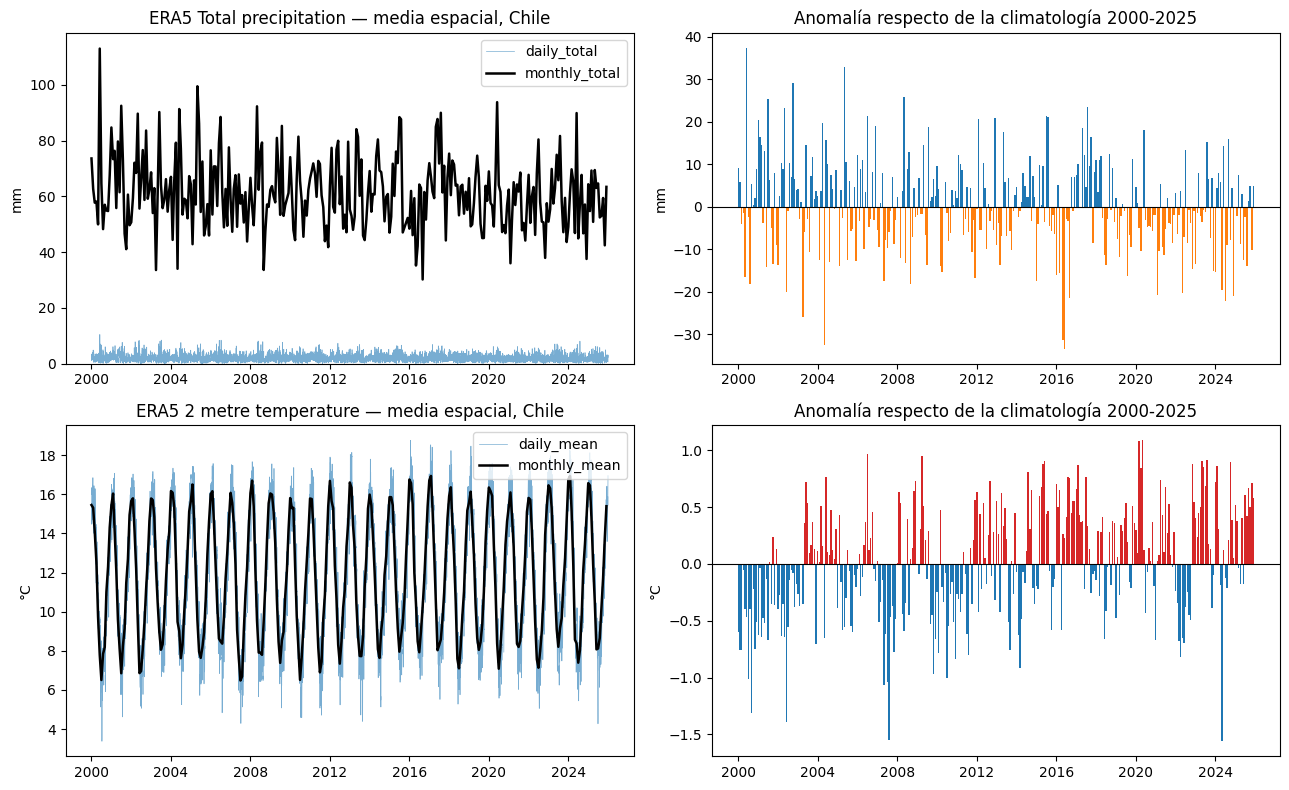

In [10]:
n_vars = len(VARIABLES)
fig, axes = plt.subplots(n_vars, 2, figsize=(13, 4 * n_vars))

if n_vars == 1:
    axes = axes.reshape(1, -1)

for idx, variable in enumerate(VARIABLES):
    ds_out, cfg, daily_agg, monthly_agg, anom, pesos = resultados[variable]

    with xr.open_dataset(SALIDA_NC[variable]) as check:
        anom_esp = (check['monthly_anomaly']
                    .weighted(np.cos(np.deg2rad(check['latitude'])))
                    .mean(('latitude', 'longitude')))

        # Gráfico 1: Series temporales
        ax1 = axes[idx, 0]
        check[cfg['spatial_daily']].plot(ax=ax1, lw=0.5, alpha=0.6, label=cfg['daily_var'])
        check[cfg['spatial_monthly']].plot(ax=ax1, lw=1.8, color='k', label=cfg['monthly_var'])
        ax1.set_title(f'ERA5 {cfg["long_name"]} — media espacial, Chile')
        ax1.set_ylabel(cfg['units'])
        ax1.set_xlabel('')
        if cfg['agg_func'] == 'sum':
            ax1.set_ylim(bottom=0)
        ax1.legend(loc='upper right')

        # Gráfico 2: Anomalías
        ax2 = axes[idx, 1]
        x = anom_esp['time_month'].values
        y = anom_esp.values
        colors = cfg['anom_color'](y)
        ax2.bar(x, y, width=np.timedelta64(25, 'D'), color=colors)
        ax2.axhline(0, color='k', lw=0.8)
        ax2.set_title(f'Anomalía respecto de la climatología {ANIO_INI}-{ANIO_FIN}')
        ax2.set_ylabel(cfg['units'])

plt.tight_layout()
plt.show()

## 10. Mapa de Chile: precipitación y temperatura para un día

Mapa espacial para un día puntual de:
- **Precipitación total acumulada** ese día (`daily_total`, suma de las 24 horas).
- **Temperatura media diaria** ese mismo día (`daily_mean`, promedio de las 24 horas).

Incluye costa, límite internacional, límites regionales de Chile (Natural Earth `admin_1`) y
grilla de coordenadas. No requiere el cluster de Dask: usa los campos diarios ya cargados en
memoria en `resultados` (sección 7).

Requiere `cartopy` (`pip install cartopy`); la primera vez descarga los shapefiles de Natural Earth.

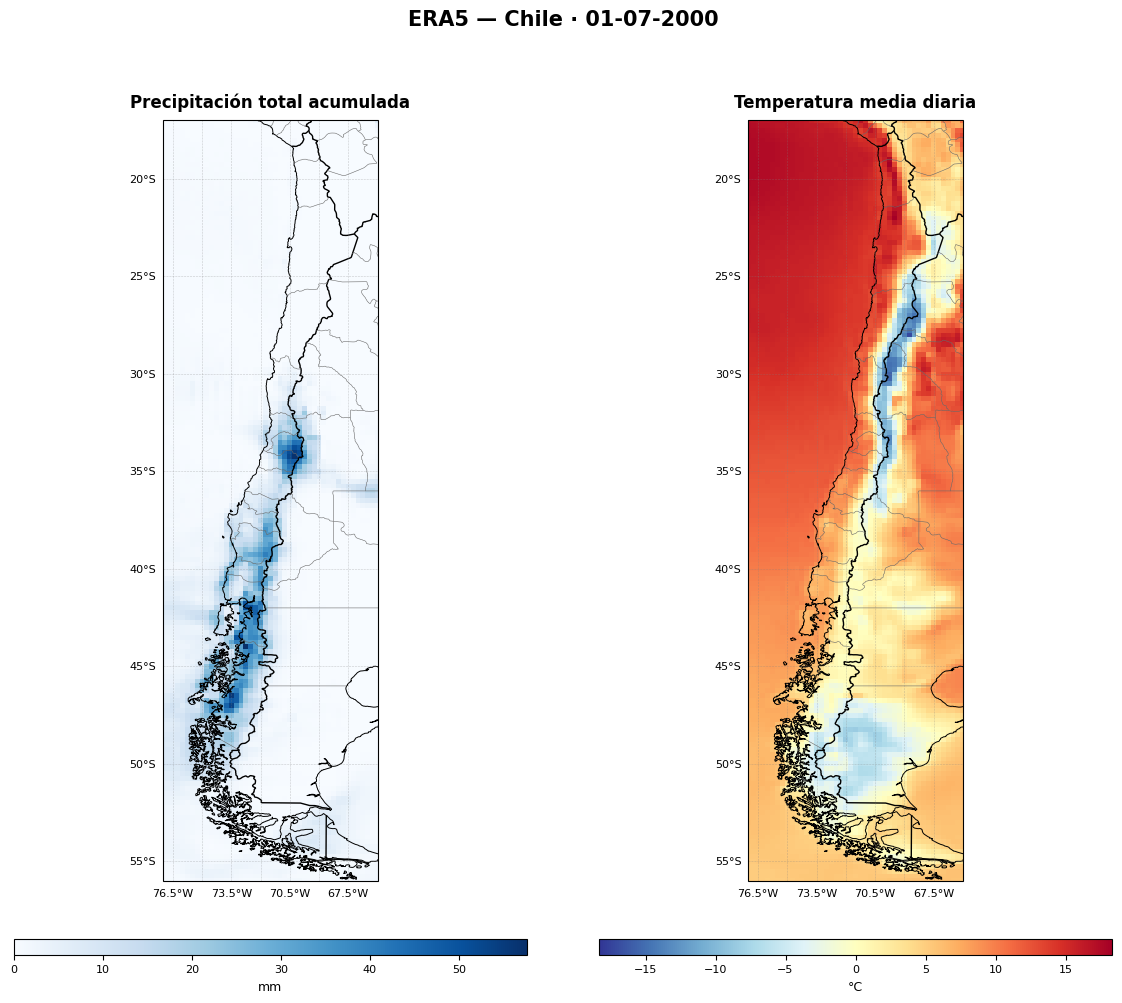

In [11]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# Día a visualizar (debe caer dentro del período ANIO_INI-ANIO_FIN ya descargado)
DIA_MAPA = '2000-07-01'
fecha_titulo = pd.Timestamp(DIA_MAPA).strftime('%d-%m-%Y')

# Título de cada panel: el estadístico diario que representa daily_agg para esa variable
DESC_DIARIA = {
    'tp': 'Precipitación total acumulada',
    't2m': 'Temperatura media diaria',
}

# Límites regionales de Chile (y del resto del mundo) desde Natural Earth
regiones = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_1_states_provinces_lines',
    scale='10m', facecolor='none',
)

cmaps = {'tp': 'Blues', 't2m': 'RdYlBu_r'}
variables_mapa = [v for v in VARIABLES if v in resultados]

fig, axes = plt.subplots(
    1, len(variables_mapa), figsize=(6.5 * len(variables_mapa), 11),
    subplot_kw={'projection': ccrs.PlateCarree()},
)
if len(variables_mapa) == 1:
    axes = [axes]

for ax, variable in zip(axes, variables_mapa):
    _, cfg, daily_agg, _, _, _ = resultados[variable]
    mapa = daily_agg.sel(time=DIA_MAPA, method='nearest')

    im = mapa.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmaps[variable], add_colorbar=False)

    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', shrink=0.75, pad=0.06, aspect=32)
    cbar.set_label(cfg['units'], fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    # costa, límite internacional y límites regionales
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linewidth=1.0, edgecolor='black')
    ax.add_feature(regiones, edgecolor='dimgray', linewidth=0.4)
    ax.set_extent([LON_OESTE, LON_ESTE, LAT_SUR, LAT_NORTE], crs=ccrs.PlateCarree())

    # grilla de coordenadas en formato geográfico (grados + N/S/E/W)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.4, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

    ax.set_title(DESC_DIARIA[variable], fontsize=12, fontweight='bold', pad=10)

fig.suptitle(f'ERA5 — Chile · {fecha_titulo}', fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 11. Cerrar el cluster

Libera los hilos del scheduler local.

In [12]:
client.close()
print('Cluster cerrado.')

Cluster cerrado.
